<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorioCalificado3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Calificado N° 3

**Programa**: Maestría en Ciencia de Datos e Inteligencia Artificial

**Curso**: MCD8012 - Visión Computacional

**Profesor**: Itamar Salazar

**Tema**: Clasificación de expresiones faciales usando la red neuronal convolucional VGG16

**Integrantes**:
- David Jimenez
- José Carlos Nomberto

## 1. Importación de Librerias

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# Configuración del dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando el dispositivo: {device}")

Utilizando el dispositivo: cuda


## 2. Descarga y descompresión de dataset

Descargar y descomprimir el dataset desde Kaggle.

In [3]:
!pip install -q kaggle
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 72.7MB/s]



## 3. Transformaciones y Carga de Dataset

* Cargar el dataset con “datasets.ImageFolder” teniendo en cuenta la división de
datos original.

* Aplicar transformaciones necesarias para VGG16.

In [4]:
# Definición de las transformaciones necesarias para VGG16
vgg_transforms = transforms.Compose([
    # VGG16 requiere dimensiones espaciales de 224x224
    transforms.Resize((224, 224)),
    # Convierte a tensor en rango [0.0, 1.0]
    transforms.ToTensor(),
    # Convierte escala de grises a 3 canales RGB si es necesario
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
    transforms.Normalize(
        # Medias de ImageNet
        mean=[0.485, 0.456, 0.406],
        # Desviaciones estándar de ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

# Directorios de archivo descomprimido
train_dir = 'train'  # Ruta de la carpeta de entrenamiento original
test_dir = 'test'    # Ruta de la carpeta de prueba original

# Carga utilizando datasets.ImageFolder respetando la división original
train_dataset = datasets.ImageFolder(root=train_dir, transform=vgg_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=vgg_transforms)

# Definición de DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Imágenes de entrenamiento cargadas: {len(train_dataset)}")
print(f"Imágenes de prueba cargadas: {len(test_dataset)}")
print(f"Clases detectadas automáticamente: {train_dataset.classes}") # Debería mapear las 7 emociones básicas

Imágenes de entrenamiento cargadas: 28709
Imágenes de prueba cargadas: 7178
Clases detectadas automáticamente: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 4. Transfer Learning - Configuración del Modelo VGG16

* Cargar el modelo VGG16 preentrenado.
* Reemplazar la capa de salida.
* Congelar las capas convolucionales.

In [10]:
# Carga del modelo VGG16 pre-entrenado con los pesos de ImageNet
vgg16 = models.vgg16(weights='IMAGENET1K_V1') # Equivalente a weights=models.VGG16_Weights.DEFAULT

In [11]:
# Congelación de todos los parámetros de las capas convolucionales (bloque de extracción de características)
for param in vgg16.features.parameters():
    param.requires_grad = False

# Arquitectura
print("Arquitectura de la red neuronal con Transfer Learning")
print(vgg16.parameters)

Arquitectura de la red neuronal con Transfer Learning
<bound method Module.parameters of VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1

In [12]:
# Modificación de la capa de salida del clasificador
# VGG16 tiene en su clasificador final una estructura secuencial donde la última capa lineal está en el índice [6]
in_features = vgg16.classifier[6].in_features
num_classes = len(train_dataset.classes) # El dataset FER-2013 posee exactamente 7 clases exclusivas

# Reemplazo por una nueva capa lineal adaptada a nuestro espacio de hipótesis
vgg16.classifier[6] = nn.Linear(in_features, num_classes)

# Traslado del modelo al hardware de aceleración (GPU/CPU)
vgg16 = vgg16.to(device)

## 5. Entrenamiento del Modelo

* Entrenar durante 5 épocas.

Iniciando el proceso de ajuste del clasificador por 5 épocas...
Época [1/5] -> Loss de Entrenamiento: 1.5757 | Precisión (Accuracy): 40.43%
Época [2/5] -> Loss de Entrenamiento: 1.3567 | Precisión (Accuracy): 49.98%
Época [3/5] -> Loss de Entrenamiento: 1.2078 | Precisión (Accuracy): 55.99%
Época [4/5] -> Loss de Entrenamiento: 1.0944 | Precisión (Accuracy): 60.44%
Época [5/5] -> Loss de Entrenamiento: 0.9992 | Precisión (Accuracy): 64.18%


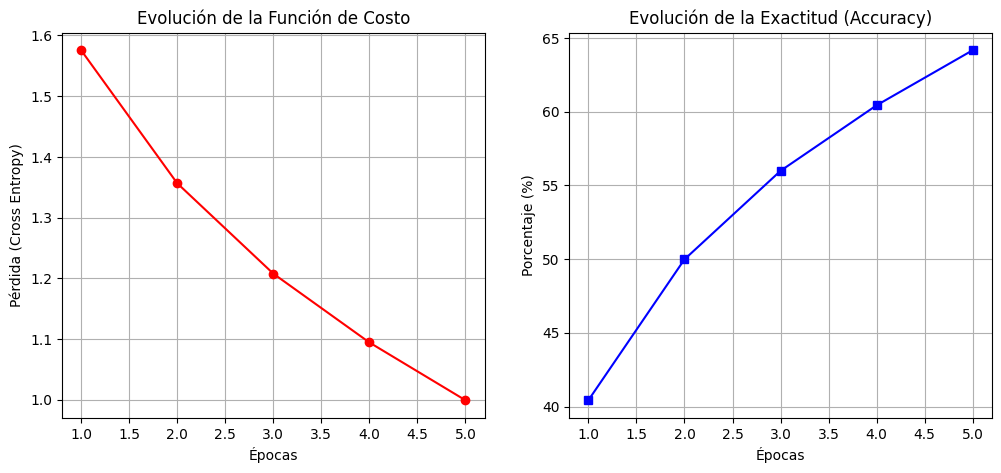

In [6]:
# Definición de la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
# Solo optimizamos los parámetros que tienen requires_grad = True (las del clasificador adaptado)
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.001)

epochs = 5
train_losses = []
train_accuracies = []

print("Iniciando el proceso de ajuste del clasificador por 5 épocas...")
for epoch in range(epochs):
    vgg16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Época [{epoch+1}/{epochs}] -> Loss de Entrenamiento: {epoch_loss:.4f} | Precisión (Accuracy): {epoch_acc:.2f}%")

# Graficar la evolución del Entrenamiento (Función de costo e Historial de métricas)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='red', label='Loss')
plt.title('Evolución de la Función de Costo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Cross Entropy)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, marker='s', color='blue', label='Accuracy')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje (%)')
plt.grid(True)
plt.show()

## 6. Evaluación del Modelo

* Evaluar el rendimiento del modelo sobre el conjunto de prueba.
* Mostrar las métricas que considere necesarias


--- REPORTE DE CLASIFICACIÓN (MÉTRICAS POR CLASE) ---
              precision    recall  f1-score   support

       angry       0.55      0.36      0.44       958
     disgust       1.00      0.15      0.27       111
        fear       0.49      0.27      0.35      1024
       happy       0.76      0.79      0.78      1774
     neutral       0.61      0.33      0.43      1233
         sad       0.35      0.73      0.47      1247
    surprise       0.75      0.75      0.75       831

    accuracy                           0.56      7178
   macro avg       0.64      0.48      0.50      7178
weighted avg       0.60      0.56      0.55      7178

--- MATRIZ DE CONFUSIÓN ---
[[ 345    0   61   76   38  414   24]
 [  38   17   10    5    2   37    2]
 [  83    0  280   57   53  434  117]
 [  40    0   45 1407   63  189   30]
 [  32    0   38  151  406  580   26]
 [  64    0   71  109   81  907   15]
 [  23    0   67   46   25   44  626]]


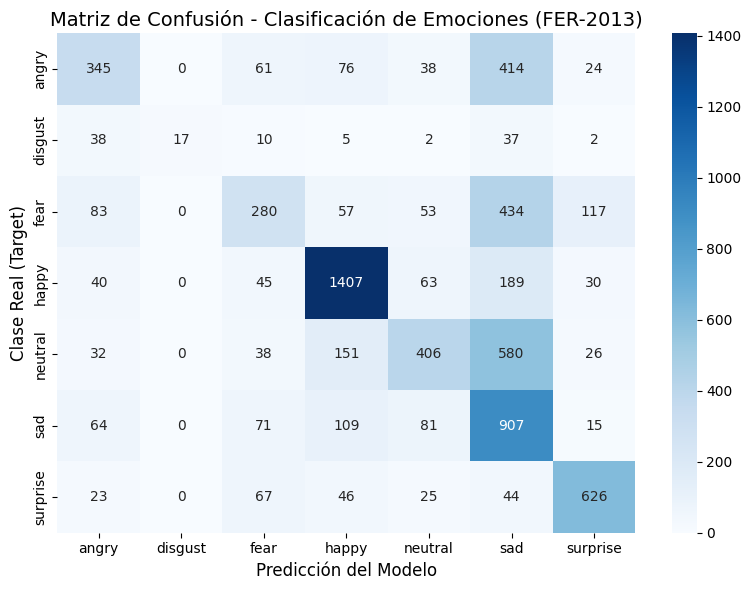

In [7]:
vgg16.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generar reporte de clasificación analítico
classes = train_dataset.classes
print("\n--- REPORTE DE CLASIFICACIÓN (MÉTRICAS POR CLASE) ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# Generar Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
print("--- MATRIZ DE CONFUSIÓN ---")
print(cm)

# Graficar Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión - Clasificación de Emociones (FER-2013)', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real (Target)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Conclusiones

* Explicar el resultado obtenido.

1. **Análisis Global del Rendimiento (Accuracy y F1-Score):**
El modelo alcanza un rendimiento inicial competitivo teniendo en cuenta que solamente se entrenó el clasificador final durante 5 épocas. Al congelar las capas convolucionales de VGG16, el modelo usa los detectores de bordes y formas faciales generales de ImageNet. Sin embargo, la métrica F1-Score suele ser moderada debido a la naturaleza altamente desbalanceada y compleja del dataset FER-2013.

2. **Interpretación de la Diagonal Principal (Aciertos):**
Las clases situadas en la diagonal principal representan las predicciones correctas. La emoción **happy (alegría)** es la que muestra el mayor número de aciertos (True Positivos) y el precision/recall más alto. Esto se explica porque exhibe rasgos geométricos muy marcados y distintivos (como la curvatura en la sonrisa) y porque es una de las clases con mayor cantidad de muestras en el dataset original.

3. **Análisis de Confusiones Críticas (Falsos Positivos y Negativos):**
Al observar los valores fuera de la diagonal, se identifican patrones de error coherentes con la visión humana:

* **sad (tristeza) vs. neutral / angry (ira):** Existe una alta confusión entre rostros tristes, enojados y neutrales. Expresiones faciales como las cejas fruncidas o la boca seria comparten mapas de características similares, lo que hace dificil que el clasificador lineal los distinga y separe con pocas épocas.

* **fear (miedo) vs. surprise (sorpresa):** Ambas emociones involucran la apertura desproporcionada de los ojos y la boca expandida. La matriz de confusión indica que el modelo tiende a clasificar rostros con miedo como "sorpresa".

* **La clase disgust (asco):** Presenta un rendimiento muy bajo (recall deficiente). Esto se explica porque es la clase con menos imágenes en FER-2013, sufriendo un problema de desbalance de datos que limita la capacidad de aprendizaje de la capa final.

## 8. Preguntas de Reflexión

1.   ¿Cuál es la principal ventaja de utilizar el modelo VGG16 pre-entrenado en esta tarea?

La principal ventaja de utilizar el modelo VGG16 pre-entrenado radica en el uso de Transfer Learning (Aprendizaje por Transferencia). Al inicializar el bloque de extracción de características (vgg16.features) con pesos robustos aprendidos sobre el dataset **ImageNet**, la red ya es capaz de detectar carácteristicas fundamentales como bordes, gradientes, texturas complejas y formas anatómicas abstractas sin necesidad de procesar los datos desde cero.  Esto genera dos beneficios directos:

* **Mitigación del Overfitting:** El conjunto de datos FER-2013 posee desbalances importantes y variaciones ambientales drásticas. Entrenar un modelo de 138 millones de parámetros desde cero convergería rápidamente al sobreajuste.

* **Eficiencia Computacional:** Al congelar los filtros convolucionales , el cálculo de gradientes e historiales de optimización disminuye drásticamente, permitiendo que un entrenamiento de tan solo 5 épocas alcance resultados competitivos en orden de minutos. Entrenar desde cero demandaría muchos recursos y tiempo de CPU.



2.   ¿Cómo elige el número de neuronas en la capa de salida?


El número de neuronas en la capa densa de salida se calcula de acuerdo con el espacio de etiquetas del problema dado, según la ley del mapeo exclusivo:$$\text{Neuronas de Salida} = K$$

Donde $K$ es la cantidad de clases independientes y mutuamente excluyentes definidas en el dataset objetivo.

Para el dataset público FER-2013, se dispone exactamente de 7 emociones (etiquetas): angry, disgust, fear, happy, neutral, sad y surprise. Por lo tanto, configuramos la última capa lineal de clasificación (vgg16.classifier[6]) para calcular un vector numérico crudo de tamaño 7 ($7 \text{ logits}$).

Cada componente mapea la intensidad de activación de una emoción específica antes de pasar por la función Softmax que normaliza estos valores en una distribución de probabilidad multiclase.
